## Comprehensive Methodology: MangoLeafVarietyBD Pipeline

This research follows a structured end-to-end computer vision pipeline, designed to enhance model robustness through advanced data synthesis and precise leaf segmentation.



### 1. Dataset Acquisition and Initial Reformatting

The process begins with the **MangoLeafVarietyBD** dataset, featuring high-resolution images of diverse mango leaf varieties in Bangladesh.

* **Format Standardization**: All raw source images (PNG/JPEG) were programmatically converted to a uniform **.jpg** format using the **Pillow** library with 95% quality retention.
* **Systematic Labeling**: To ensure metadata integrity, images were renamed following the `{Variety_Name}_{Index}.jpg` convention before further processing.



### 2. Multi-Modal Data Augmentation (Pre-segmentation)

To mitigate overfitting and simulate real-world environmental variance, a six-stage sequential augmentation pipeline was executed **prior to background removal**:

1. **Geometric Rotation**: Random rotations within $\pm 15^\circ$ to $\pm 45^\circ$.
2. **Reflection Mapping**: Horizontal and vertical flipping for perspective variance.
3. **Luminance Adjustment**: Brightness scaling ($0.6\times$ to $1.4\times$) for lighting simulation.
4. **Affine Shearing**: Simulating camera angle distortions.
5. **Gaussian Smoothing**: Representing out-of-focus or low-resolution captures.
6. **Contrast Manipulation**: Enhancing feature discriminability.



### 3. Leaf Segmentation and Spatial Normalization

Following the augmentation phase, the dataset underwent advanced preprocessing to focus exclusively on leaf morphology:

* **Background Removal**: The **rembg** library (based on the U-2-Net architecture) was utilized to isolate the mango leaf from complex environmental backgrounds, replacing it with a clean, neutral canvas.
* **Resizing & Saving**: All processed samples were resized to a fixed resolution of **224x224 pixels** using **Lanczos interpolation** to maintain edge detail and were systematically saved to **Google Drive** for persistent storage and model training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Renaming of images according to class**

In [ ]:
# ==============================================================================
# DATASET STANDARDIZATION AND REFORMATTING PIPELINE
# Description: This script performs batch renaming of images according to class
# labels and ensures uniform JPEG encoding for consistency across the dataset.
# ==============================================================================

import os
from PIL import Image

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
# Path to the source directory containing sub-folders for each mango variety
dataset_path = "/content/drive/MyDrive/Mango Leaf Dataset/Raw Data"

def standardize_dataset_filenames(base_path):
    """
    Iterates through class-specific directories to rename files numerically
    and convert all images to high-quality JPEG format.
    """
    if not os.path.exists(base_path):
        print(f"[ERROR] Directory not found: {base_path}")
        return

    print(f"[STATUS] Initializing dataset standardization in: {base_path}")

    # Iterate through each category (variety) folder
    for class_name in sorted(os.listdir(base_path)):
        class_folder = os.path.join(base_path, class_name)

        if os.path.isdir(class_folder):
            # Retrieve all valid image files and sort alphabetically for consistency
            valid_extensions = ('.jpg', '.jpeg', '.png')
            images = [f for f in os.listdir(class_folder) if f.lower().endswith(valid_extensions)]
            images.sort()

            print(f"[LOG] Processing variety: '{class_name}' | Total: {len(images)} images")

            # Sequential renaming and format conversion loop
            for idx, img_name in enumerate(images, start=1):
                img_path = os.path.join(class_folder, img_name)

                # Define standardized filename pattern (e.g., VarietyName_001.jpg)
                new_filename = f"{class_name}_{idx:03d}.jpg"
                new_path = os.path.join(class_folder, new_filename)

                try:
                    # Open source image and ensure conversion to RGB for JPEG compatibility
                    with Image.open(img_path) as img:
                        rgb_img = img.convert('RGB')
                        # Save with high-quality JPEG compression (Standard for Computer Vision)
                        rgb_img.save(new_path, "JPEG", quality=95)

                    # Remove the legacy file if it has a different name or extension
                    if os.path.abspath(img_path) != os.path.abspath(new_path):
                        os.remove(img_path)

                except Exception as e:
                    print(f"[ERROR] Failed to process {img_name}: {str(e)}")

# ------------------------------------------------------------------------------
# 3. EXECUTION
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    standardize_dataset_filenames(dataset_path)
    print("All images renamed and saved as JPG successfully!")

All images renamed and saved as JPG successfully!


# **DATASET DISTRIBUTION ANALYSIS**

In [ ]:
# ==============================================================================
# DATASET DISTRIBUTION ANALYSIS
# Description: This script calculates the number of samples per class and
# determines the total dataset volume for statistical verification.
# ==============================================================================

import os

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
# Ensure dataset_path is defined (pointing to your mango leaf dataset)
# Example: dataset_path = "/content/drive/MyDrive/Mango Leaf Dataset/Raw Images"

def count_dataset_samples(dataset_path):
    """
    Iterates through class directories to count image files and
    summarizes the total dataset size.
    """
    if not os.path.exists(dataset_path):
        print(f"[ERROR] Path not found: {dataset_path}")
        return

    total_images = 0
    print("Number of images per class:\n")

    # Iterate through each directory (class/variety) in the dataset
    # sorted() ensures the output is always in alphabetical order
    for class_name in sorted(os.listdir(dataset_path)):
        class_folder = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_folder):
            # Count valid image files within the specific class folder
            # Supporting common formats: .jpg, .jpeg, .png
            valid_extensions = ('.jpg', '.jpeg', '.png')
            image_list = [f for f in os.listdir(class_folder) if f.lower().endswith(valid_extensions)]
            image_count = len(image_list)

            total_images += image_count

            # Display individual class statistics
            print(f"{class_name}: {image_count} images")

    # Display aggregate results
    print(f"\nTotal dataset size: {total_images} images")

# ------------------------------------------------------------------------------
# 2. EXECUTION
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    count_dataset_samples(dataset_path)

Number of images per class:

Amrupali: 308 images
Banana: 351 images
Brunei King: 300 images
Harivanga: 366 images
Surjapuri: 370 images
Kacha Mitha: 376 images
Himsagor: 341 images
Bandigori: 332 images

Total dataset size: 2744 images


# **Raw Dataset View**

[INFO] Generating aligned 4x4 grid with Class Boxes...
[SUCCESS] Standardized boxed grid view saved to: /content/drive/MyDrive/Dataset/Mango Leaf Data/View/Raw_Dataset_View_Boxed.png


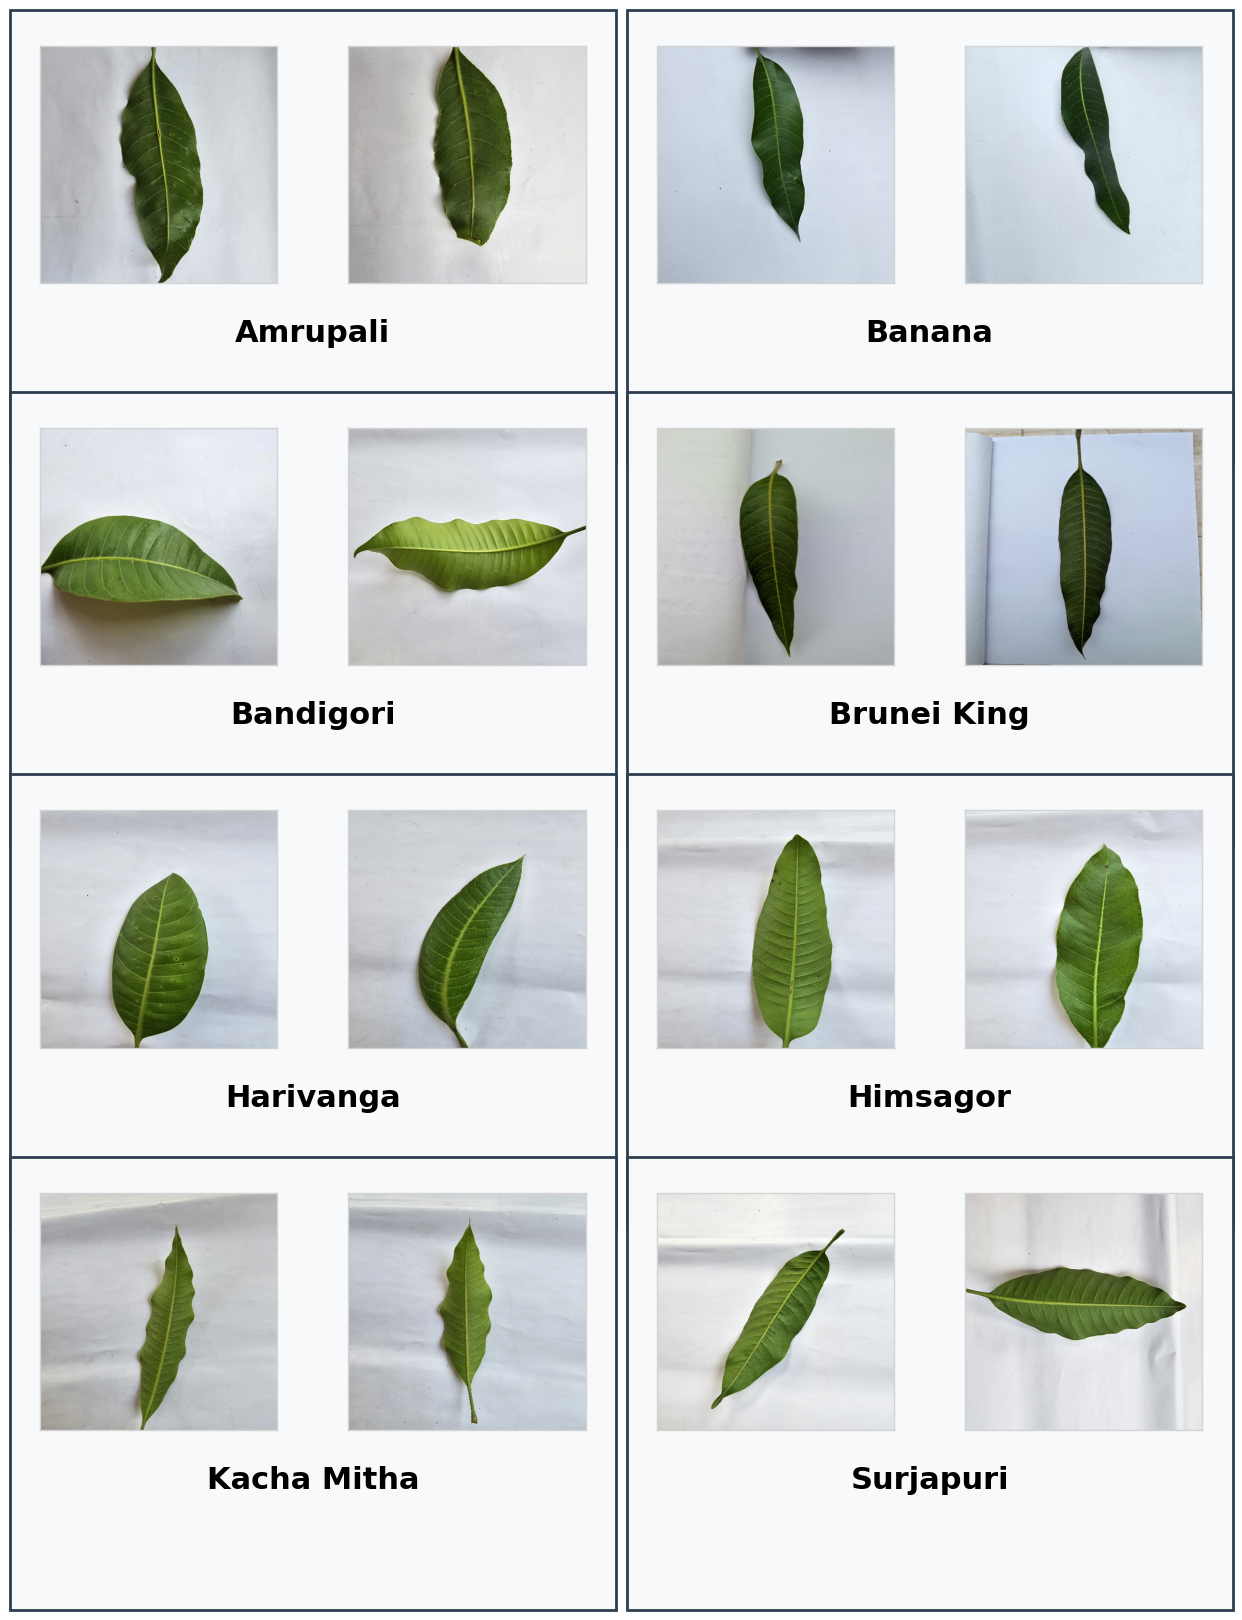

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import random

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
RAW_DATA_PATH = Path('/content/drive/MyDrive/Dataset/Mango Leaf Data/Raw Data')
OUT_DIR = Path("/content/drive/MyDrive/Dataset/Mango Leaf Data/View")
OUT_DIR.mkdir(exist_ok=True, parents=True)

# ==============================================================================
# 2. IMPROVED CLASS-WISE VIEW MODULE (WITH BOUNDING BOXES)
# ==============================================================================
def generate_aligned_raw_view(dataset_path, rows=4, classes_per_row=2, images_per_class=2):
    """
    Generates a 4x4 grid:
    Each class (2 images + 1 name) is enclosed in a stylish bounding box.
    Total 8 classes displayed across 4 rows.
    """
    if not dataset_path.exists():
        print(f"[ERROR] Path not found: {dataset_path}")
        return

    # Identify all classes and sort them
    classes = sorted([d for d in os.listdir(dataset_path) if (dataset_path / d).is_dir()])
    cols = classes_per_row * images_per_class

    # Set up figure
    fig, axes = plt.subplots(rows, cols, figsize=(15, 18))

    # Adjust spacing to make room for boxes and text
    plt.subplots_adjust(wspace=0.3, hspace=0.6)

    print(f"[INFO] Generating aligned {rows}x{cols} grid with Class Boxes...")

    for row_idx in range(rows):
        for class_pos in range(classes_per_row):
            class_idx = row_idx * classes_per_row + class_pos
            col_start = class_pos * images_per_class

            if class_idx < len(classes):
                class_name = classes[class_idx]
                class_dir = dataset_path / class_name
                images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

                selected_imgs = random.sample(images, min(len(images), images_per_class))

                # Draw the images
                for i in range(images_per_class):
                    ax = axes[row_idx, col_start + i]
                    if i < len(selected_imgs):
                        img_path = class_dir / selected_imgs[i]
                        img = cv2.imread(str(img_path))
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                        img = cv2.resize(img, (500, 500))
                        ax.imshow(img)

                    # Clean individual image borders
                    ax.set_xticks([])
                    ax.set_yticks([])
                    for spine in ax.spines.values():
                        spine.set_visible(True)
                        spine.set_color('lightgrey')
                        spine.set_linewidth(1.0)

                # ====== CLASS NAME PLACEMENT ======
                ax_left = axes[row_idx, col_start]
                ax_right = axes[row_idx, col_start + 1]

                # Ekhane Font size 14 theke 22 kora hoyeche ebong text aro bold kora hoyeche
                ax_left.text(
                    x=1.15, y=-0.15, s=class_name,
                    transform=ax_left.transAxes,
                    fontsize=22, fontweight='heavy',
                    ha='center', va='top', color='black'
                )

                # ====== DRAWING THE BOX AROUND THE CLASS ======
                # Force an update to get exact positions
                fig.canvas.draw()

                pos_left = ax_left.get_position()
                pos_right = ax_right.get_position()

                # Calculate coordinates for the box around the 2 images and text
                # Text boro howay nicher padding (y0 and height) ektu barano hoyeche jate text box er vitor thake
                x0 = pos_left.x0 - 0.02
                y0 = pos_left.y0 - 0.10
                width = pos_right.x1 - pos_left.x0 + 0.04
                height = pos_left.y1 - pos_left.y0 + 0.12

                # Add a stylish rectangle patch
                rect = patches.Rectangle(
                    (x0, y0), width, height,
                    linewidth=2, edgecolor='#2c3e50', facecolor='#f8f9fa',
                    transform=fig.transFigure, clip_on=False, zorder=-1
                )
                fig.patches.append(rect)

    # Save the professional version to Drive
    save_path = OUT_DIR / "Raw_Dataset_View_Boxed.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print(f"[SUCCESS] Standardized boxed grid view saved to: {save_path}")
    plt.show()

# ==============================================================================
# 3. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    generate_aligned_raw_view(RAW_DATA_PATH, rows=4, classes_per_row=2, images_per_class=2)

# **Augmentation + Background Remove + Resize**

In [ ]:
# ==============================================================================
# DATA PREPROCESSING AND MULTI-MODAL AUGMENTATION PIPELINE
# Description: This script performs background removal, normalization,
# and six distinct types of image augmentation to enhance model robustness.
# ==============================================================================

import os
import random
import numpy as np
from PIL import Image, ImageEnhance, ImageOps, ImageFilter
from rembg import remove

# ------------------------------------------------------------------------------
# 1. GLOBAL CONFIGURATION
# ------------------------------------------------------------------------------
# Define source and destination directories for reproducible experiments
dataset_path = "/content/drive/MyDrive/Mango Leaf Dataset/Raw Images"
output_augmented = "/content/drive/MyDrive/Mango Leaf Dataset/Augmented Images"
os.makedirs(output_augmented, exist_ok=True)

# Standardize image dimensions for Deep Learning model input (e.g., ResNet/DenseNet)
image_size = (224, 224)

# Set deterministic seeds to ensure reproducibility across different runs
random.seed(42)
np.random.seed(42)

# ------------------------------------------------------------------------------
# 2. DEFINING AUGMENTATION PRIMITIVES
# ------------------------------------------------------------------------------

def rotate_image(img):
    """Applies random geometric rotation within defined angular constraints."""
    angle = random.choice([15, -15, 30, -30, 45, -45])
    return img.rotate(angle), f"Rotation{angle}deg"

def flip_image(img):
    """Performs reflection mapping (Horizontal/Vertical) to simulate perspective variance."""
    flip_type = random.choice(["Horizontal", "Vertical"])
    if flip_type == "Horizontal":
        return img.transpose(Image.FLIP_LEFT_RIGHT), "FlipHorizontal"
    else:
        return img.transpose(Image.FLIP_TOP_BOTTOM), "FlipVertical"

def brightness_image(img):
    """Adjusts luminance levels to simulate diverse environmental lighting conditions."""
    factor = random.uniform(0.6, 1.4)
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor), f"Brightness{factor:.2f}"

def shear_image(img):
    """Applies affine transformation (Shearing) to simulate camera-angle distortion."""
    shear_factor = random.choice([10, -10, 15, -15, 20, -20])
    w, h = img.size
    matrix = (1, np.tan(np.radians(shear_factor)), 0, 0, 1, 0)
    img_sheared = img.transform((w, h), Image.AFFINE, matrix, Image.BICUBIC, fillcolor=(255,255,255))
    return img_sheared, f"Shear{shear_factor}deg"

def blur_image(img):
    """Applies Gaussian smoothing to represent out-of-focus or low-resolution captures."""
    sigma = random.uniform(0.5, 1.0)
    return img.filter(ImageFilter.GaussianBlur(radius=sigma)), f"Blur{sigma:.2f}"

def contrast_image(img):
    """Manipulates color intensity levels to enhance feature discriminability."""
    factor = random.uniform(0.7, 1.3)
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor), f"Contrast{factor:.2f}"

# ------------------------------------------------------------------------------
# 3. SEGMENTATION AND PREPROCESSING MODULE
# ------------------------------------------------------------------------------

def remove_bg_and_resize(img):
    """
    Executes deep-learning based background subtraction and resizes to
    target resolution using Lanczos interpolation.
    """
    img_no_bg = remove(img)
    img_rgb = Image.new("RGB", img_no_bg.size, (255, 255, 255))
    img_rgb.paste(img_no_bg, mask=img_no_bg.split()[3])
    return img_rgb.resize(image_size, Image.LANCZOS)

# ------------------------------------------------------------------------------
# 4. DATASET EXECUTION PIPELINE
# ------------------------------------------------------------------------------

def process_dataset(dataset_path, output_augmented):
    """Main execution loop for class-wise image processing and augmentation."""
    for cls in sorted(os.listdir(dataset_path)):
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        save_cls_path = os.path.join(output_augmented, cls)
        os.makedirs(save_cls_path, exist_ok=True)
        print(f"[LOG] Processing variety: {cls}")

        for img_name in sorted(os.listdir(cls_path)):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(cls_path, img_name)
            try:
                img = Image.open(img_path).convert("RGB")

                # Step 1: Baseline preprocessing (BG removal + Resizing)
                img_clean = remove_bg_and_resize(img)
                base_name = os.path.splitext(img_name)[0]
                img_clean.save(os.path.join(save_cls_path, f"{base_name}_Original.jpg"))

                # Step 2: Sequential application of the 6 augmentation techniques
                funcs = [rotate_image, flip_image, brightness_image, shear_image, blur_image, contrast_image]
                for i, func in enumerate(funcs, start=1):
                    aug_img, aug_name = func(img_clean)
                    # Re-apply resizing to maintain dimensional consistency post-transformation
                    final_aug = aug_img.resize(image_size, Image.LANCZOS)
                    final_aug.save(os.path.join(save_cls_path, f"{base_name}_aug{i}_{aug_name}.jpg"))

            except Exception as e:
                print(f"[ERROR] Failed to process {img_name}: {str(e)}")

# START PROCESSING
if __name__ == "__main__":
    process_dataset(dataset_path, output_augmented)
    print("\n[SUCCESS] Pipeline execution finalized. Dataset is ready for model training.")

# **Raw And Augmented Dataset Simple Showing**

[STATUS] Initializing grid generation for 4 rows...
[SUCCESS] High-resolution figure exported to: /content/drive/MyDrive/Mango Leaf Dataset/View/Figure_Dataset_Augmentation_Samples.png


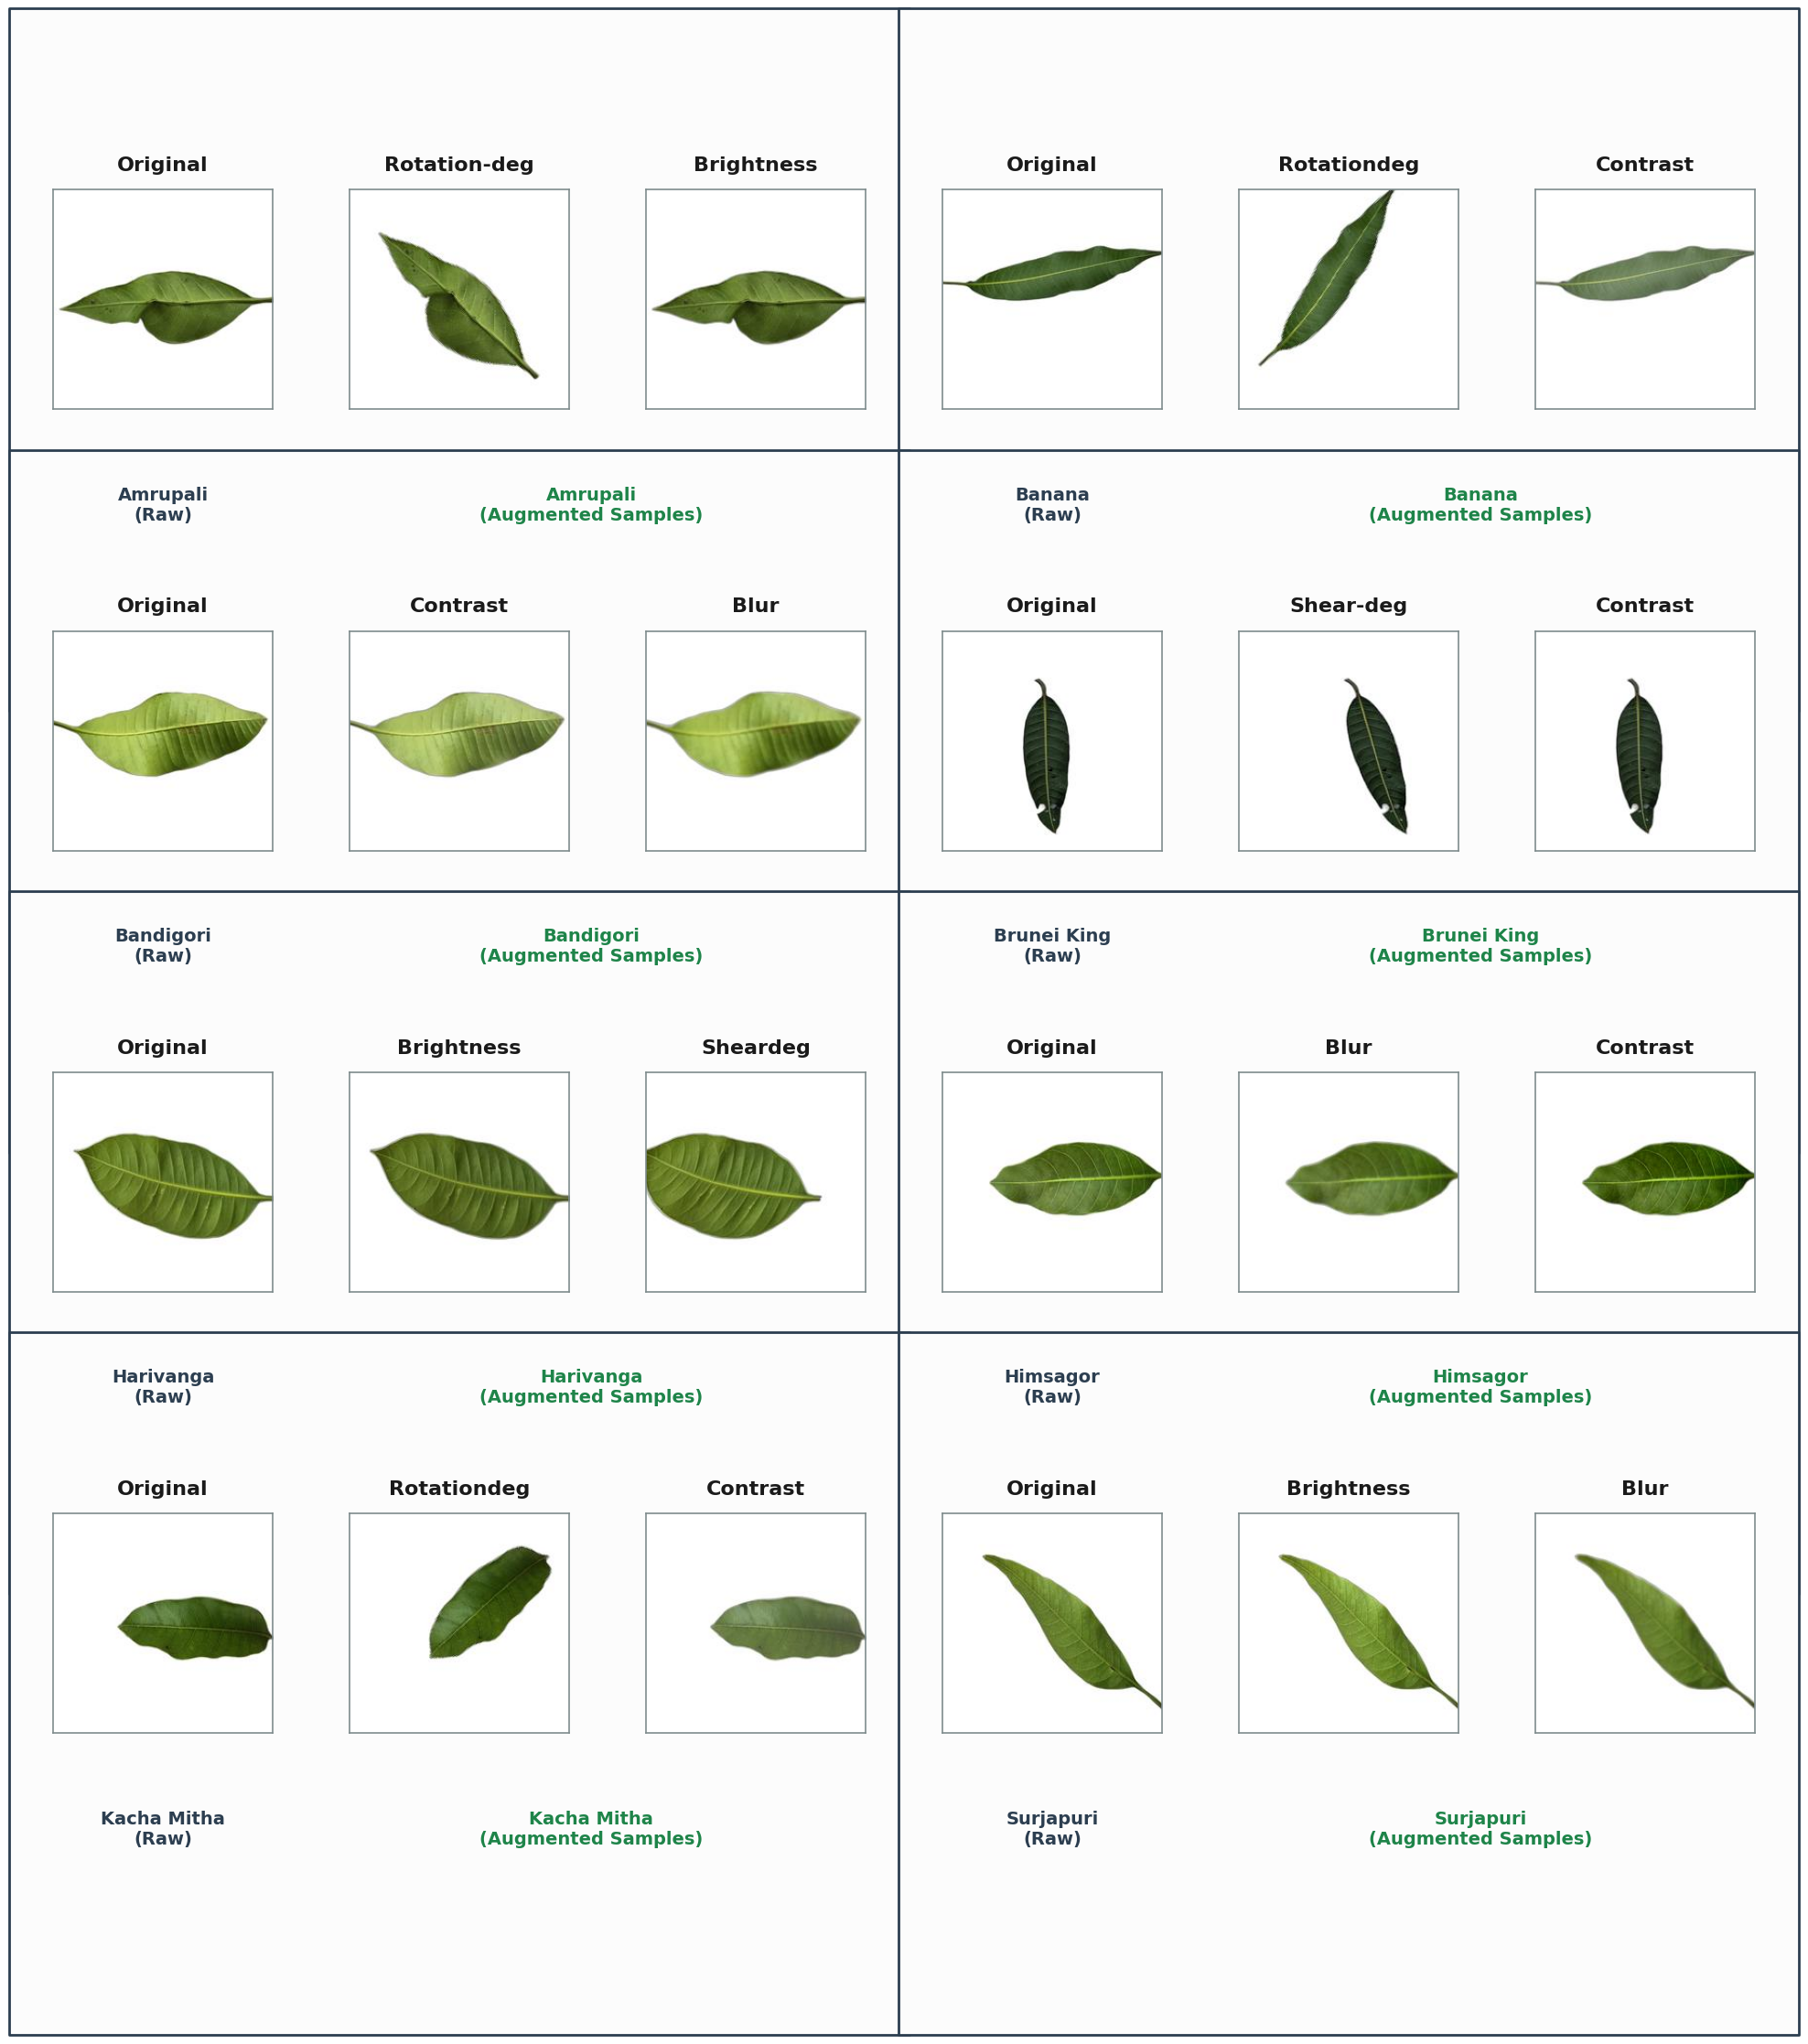

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import random
import numpy as np

# ==============================================================================
# 1. CONFIGURATION AND PATH SETUP
# ==============================================================================
# Define dataset directory and output path for visualization
DATASET_ROOT = Path('/content/drive/MyDrive/Mango Leaf Dataset/Augmented Images')
OUTPUT_DIRECTORY = Path("/content/drive/MyDrive/Mango Leaf Dataset/View")

# Ensure the output directory exists
OUTPUT_DIRECTORY.mkdir(exist_ok=True, parents=True)

# ==============================================================================
# 2. CORE VISUALIZATION MODULE
# ==============================================================================
def generate_academic_data_visualization(dataset_path, num_rows=4, classes_per_row=2):
    """
    Generates a high-resolution grid layout demonstrating raw and augmented
    samples per class for academic publication.
    """
    if not dataset_path.exists():
        print(f"[ERROR] Invalid directory path: {dataset_path}")
        return

    # Retrieve and sort class names for consistent ordering
    class_list = sorted([d for d in os.listdir(dataset_path) if (dataset_path / d).is_dir()])
    samples_per_class = 3
    total_cols = classes_per_row * samples_per_class

    # Initialize figure with white background for journal standards
    fig, axes = plt.subplots(num_rows, total_cols, figsize=(24, 22), facecolor='white')

    # Adjust spacing to ensure label clarity and prevent bounding box overlap
    plt.subplots_adjust(wspace=0.35, hspace=0.95)

    print(f"[STATUS] Initializing grid generation for {num_rows} rows...")

    for row_idx in range(num_rows):
        for class_pos in range(classes_per_row):
            current_class_idx = row_idx * classes_per_row + class_pos
            column_offset = class_pos * samples_per_class

            if current_class_idx < len(class_list):
                target_class = class_list[current_class_idx]
                target_dir = dataset_path / target_class

                # Filter valid image formats
                valid_extensions = ('.png', '.jpg', '.jpeg')
                image_files = [f for f in os.listdir(target_dir) if f.lower().endswith(valid_extensions)]

                # Separate raw (original) from augmented data based on naming convention
                raw_pool = [f for f in image_files if '_original' in f.lower()]
                if not raw_pool:
                    continue

                # Select a random base image to show its specific augmentations
                selected_raw = random.choice(raw_pool)
                # Extract identifier to find related augmented versions
                base_identifier = selected_raw.lower().split('_original')[0]

                augmented_pool = [f for f in image_files if base_identifier in f.lower() and '_original' not in f.lower()]

                # Assemble display list: [Original, Aug_Sample_1, Aug_Sample_2]
                display_queue = [selected_raw]
                if len(augmented_pool) >= 2:
                    display_queue.extend(random.sample(augmented_pool, 2))
                else:
                    display_queue.extend(augmented_pool)

                # Render images within the specific grid segment
                for i in range(samples_per_class):
                    ax = axes[row_idx, column_offset + i]

                    if i < len(display_queue):
                        image_path = target_dir / display_queue[i]
                        img_data = cv2.imread(str(image_path))
                        img_data = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB)
                        ax.imshow(img_data)

                        # Extract transformation type from filename for descriptive labeling
                        if i == 0:
                            label_header = "Original"
                        else:
                            try:
                                # Parse the augmentation type from the last segment of the filename
                                suffix = display_queue[i].split('_')[-1].split('.')[0]
                                label_header = ''.join([c for c in suffix if not c.isdigit()]).replace('.', '')
                            except (IndexError, AttributeError):
                                label_header = "Augmented"

                        # Set bold subplot titles (Transformation types)
                        ax.set_title(label_header, fontsize=16, pad=15, fontweight='bold', color='#1a1a1a')

                        # Set bold class identifiers with vertical padding to avoid overlap
                        if i == 0:
                            ax.text(0.5, -0.35, f"{target_class}\n(Raw)", transform=ax.transAxes,
                                    fontsize=14, fontweight='bold', ha='center', va='top', color='#2c3e50')
                        elif i == 1:
                            # Positioned between the two augmented samples for logical grouping
                            ax.text(1.1, -0.35, f"{target_class}\n(Augmented Samples)", transform=ax.transAxes,
                                    fontsize=14, fontweight='bold', ha='center', va='top', color='#1e8449')

                    # Remove axis ticks for a clean aesthetic
                    ax.set_xticks([])
                    ax.set_yticks([])

                    # Style subplot spines
                    for edge in ax.spines.values():
                        edge.set_linewidth(1.2)
                        edge.set_color('#7f8c8d')

                # --- Draw Bounding Rectangle for Class Grouping ---
                fig.canvas.draw()
                start_box = axes[row_idx, column_offset].get_position()
                end_box = axes[row_idx, column_offset + 2].get_position()

                # Calculate relative coordinates for grouping patches
                rect_x = start_box.x0 - 0.02
                rect_y = start_box.y0 - 0.15
                rect_w = end_box.x1 - start_box.x0 + 0.04
                rect_h = start_box.y1 - start_box.y0 + 0.24

                # Append grouping rectangle to the figure
                grouping_patch = patches.Rectangle(
                    (rect_x, rect_y), rect_w, rect_h,
                    linewidth=2.0, edgecolor='#2c3e50', facecolor='#fcfcfc',
                    transform=fig.transFigure, clip_on=False, zorder=-1,
                    joinstyle='round'
                )
                fig.patches.append(grouping_patch)

    # Export visualization at 600 DPI for high-impact journals
    final_output_path = OUTPUT_DIRECTORY / "Figure_Dataset_Augmentation_Samples.png"
    plt.savefig(final_output_path, dpi=600, bbox_inches='tight', facecolor='white')

    print(f"[SUCCESS] High-resolution figure exported to: {final_output_path}")
    plt.show()

# ==============================================================================
# 3. EXECUTION FLOW
# ==============================================================================
if __name__ == "__main__":
    # Reproducibility seed for consistent figure generation
    random.seed(42)
    generate_academic_data_visualization(DATASET_ROOT, num_rows=4, classes_per_row=2)